<a href="https://colab.research.google.com/github/adithya0x/Optimal-Portfolio-Allocation/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## WEEK-2 Assignment
Fill the missing places wherever TO DO is mentioned and also understnad what has been done properly


**Also give explanation about each graph and what all you understood about it by adding a text cell below the respective graph**

Do not use Chatgpt . It is a simple assignment. Make a copy of this colab notebook and do your changes and submit it as `Assignment2_yourrollno.ipnyb`


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS"] #you can choose assets of your own wish

df = yf.download(TICKERS, period="3y")
prices = df.xs("Close", axis=1, level=0)

prices = prices.fillna(method="ffill").dropna()
prices.head()


/tmp/ipykernel_14951/4023598879.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKERS, period="3y")
[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_14951/4023598879.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prices = prices.fillna(method="ffill").dropna()


Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Date,,,
2023-05-08,791.256287,1128.413940,2989.478760
2023-05-09,791.280396,1131.906250,3019.506592
2023-05-10,794.937195,1139.689575,3022.771240
2023-05-11,795.466492,1132.248657,3018.494629
2023-05-12,802.491638,1134.097412,3011.275635


In [5]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()

Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Date,,,
2023-05-09,0.000030,0.003090,0.009994
2023-05-10,0.004611,0.006853,0.001081
2023-05-11,0.000666,-0.006550,-0.001416
2023-05-12,0.008793,0.001631,-0.002394
2023-05-15,0.004785,0.001970,-0.005897


In [6]:
TRADING_DAYS = 252
mu = log_returns.mean() * TRADING_DAYS
cov_matrix = log_returns.cov() * TRADING_DAYS

mu, cov_matrix


(Ticker
 HDFCBANK.NS    0.002054
 RELIANCE.NS    0.082023
 TCS.NS        -0.074494
 dtype: float64,
 Ticker       HDFCBANK.NS  RELIANCE.NS    TCS.NS
 Ticker                                         
 HDFCBANK.NS     0.038153     0.014665  0.006561
 RELIANCE.NS     0.014665     0.042980  0.010981
 TCS.NS          0.006561     0.010981  0.044524)

In [7]:
# step controls how finely we explore the portfolio weight space.
# step = 0.02 means weights change in increments of 2%:
# 0.00, 0.02, 0.04, ..., 1.00
# Smaller step  -> more portfolios -> higher accuracy -> slower computation
# Larger step  -> fewer portfolios -> faster but coarser approximation
step = 0.02  # You can consider some other step sizes too
weights = []   # This list will store all VALID portfolios. Each portfolio is a vector: [w1, w2, w3]


# Loop over possible values of weight for Asset 1
for w1 in np.arange(0, 1 + step, step):
    # For each w1, loop over possible values of weight for Asset 2
    for w2 in np.arange(0, 1 + step, step):
        w3 = 1.0 - w1 - w2
        if w3 >= -1e-7:
            weights.append([w1, w2, w3])

weights = np.array(weights)
print(f"Number of feasible portfolios generated: {len(weights)}")


Number of feasible portfolios generated: 1326


In [8]:
# Lists to store portfolio returns and volatility
portfolio_returns = []
portfolio_volatility = []


# Loop over every feasible portfolio weight vector
for w in weights:
    ret = np.dot(w, mu)
    var = np.dot(w, np.dot(cov_matrix, w))

    portfolio_returns.append(ret)
    portfolio_volatility.append(np.sqrt(var))

portfolio_df = pd.DataFrame(weights, columns=["w1", "w2", "w3"])
portfolio_df["Return"] = portfolio_returns
portfolio_df["Volatility"] = portfolio_volatility

portfolio_df.head()


,w1,w2,w3,Return,Volatility
0,0.0,0.00,1.00,-0.074494,0.211007
1,0.0,0.02,0.98,-0.071363,0.207866
2,0.0,0.04,0.96,-0.068233,0.204805
3,0.0,0.06,0.94,-0.065103,0.201828
4,0.0,0.08,0.92,-0.061972,0.198938


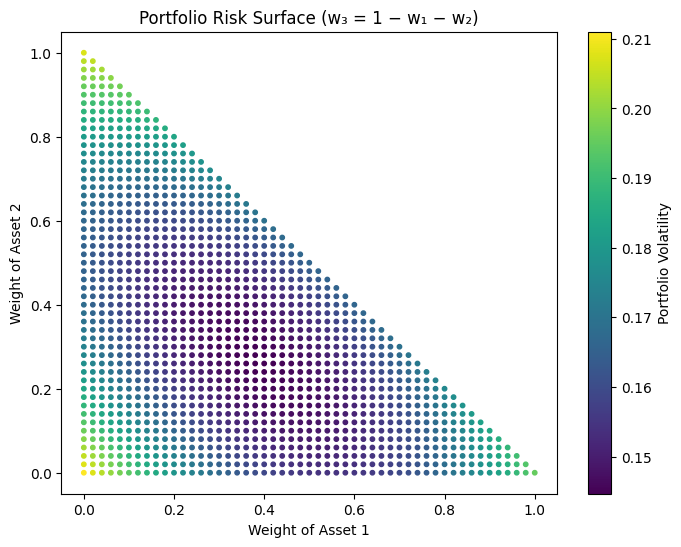

In [20]:
#Visualization for Risk Surface
plt.figure(figsize=(8,6))
sc = plt.scatter(
    portfolio_df["w1"],
    portfolio_df["w2"],
    c=portfolio_df["Volatility"],
    cmap="viridis",
    s=10
)

plt.colorbar(sc, label="Portfolio Volatility")
plt.xlabel("Weight of Asset 1")
plt.ylabel("Weight of Asset 2")
plt.title("Portfolio Risk Surface (w₃ = 1 − w₁ − w₂)")
plt.show()


### 1. Portfolio Risk Surface
This heat map visualizes the total risk (volatility) of the portfolio based on the allocation to Asset 1 and Asset 2. Because $w_3$ is mathematically constrained to $1 - w_1 - w_2$, any coordinate on this plot represents a fully allocated portfolio (100% capital deployed).

The darker purple and blue "valleys" indicate the specific weight combinations that minimize variance through diversification, effectively showing the global minimum variance region in the weight space.

In [11]:
min_var_idx = portfolio_df["Volatility"].idxmin()
min_var_portfolio = portfolio_df.loc[min_var_idx]

print("\nMinimum Variance Portfolio:")
print(min_var_portfolio)


Minimum Variance Portfolio:
w1            0.380000
w2            0.280000
w3            0.340000
Return       -0.001581
Volatility    0.144681
Name: 812, dtype: float64


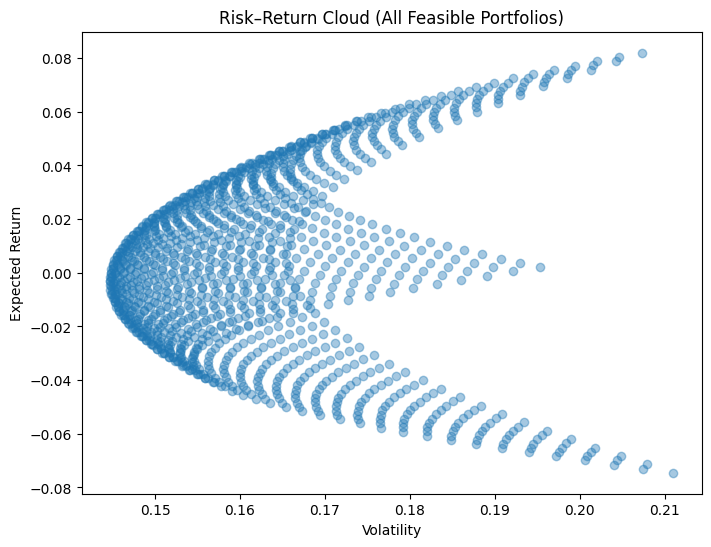

In [12]:
# Risk-Return for all Portfolios (Visualization)
plt.figure(figsize=(8,6))
plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Return"],
    alpha=0.4
)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Risk–Return Cloud (All Feasible Portfolios)")
plt.show()


### 2. Risk-Return Cloud
This scatter plot maps out every generated feasible portfolio in the risk-return plane (often referred to as the Markowitz Bullet).

It demonstrates a core tenet of modern finance: for any given level of risk on the x-axis, there are multiple possible portfolio allocations. However, a rational investor will only care about the highest point on the y-axis (the maximum expected return) for that specific level of risk.

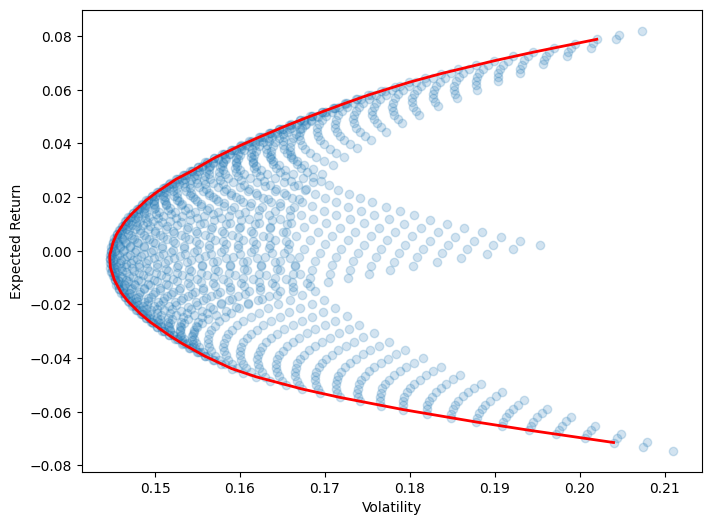

In [14]:
bins = np.linspace(
    portfolio_df["Return"].min(),
    portfolio_df["Return"].max(),
    40
)

frontier_risk = []
frontier_return = []

for i in range(len(bins)-1):
    mask = (portfolio_df["Return"] >= bins[i]) & (portfolio_df["Return"] < bins[i+1])
    subset = portfolio_df[mask]

    if len(subset) > 0:
        min_row = subset.loc[subset["Volatility"].idxmin()]
        frontier_risk.append(min_row["Volatility"])
        frontier_return.append(min_row["Return"])

plt.figure(figsize=(8,6))
plt.scatter(portfolio_df["Volatility"], portfolio_df["Return"], alpha=0.2)
plt.plot(frontier_risk, frontier_return, color="red", linewidth=2)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.show()


### 3. The Efficient Frontier
The red line plotted over the cloud is called the **Efficient Frontier**. Mathematically, it represents the set of Pareto-optimal portfolios, tracing the absolute upper-left edge of the risk-return cloud.

Portfolios that lie exactly on this line offer the maximum possible expected return for their specific level of volatility. Any portfolio sitting below this line is considered "inefficient" because an investor could theoretically move straight up to the red line to gain more return without taking on any additional risk.

In [15]:
# Controlled stress test on diversification
# Increase covariance to simulate higher correlation. This mimics market stress where assets move together
stressed_cov = cov_matrix.copy()

for i in range(len(stressed_cov)):
    for j in range(len(stressed_cov)):
        if i != j:
            stressed_cov.iloc[i, j] *= 2    # Can change the factor from 2 to any other no. too. Try chaging to diff values


In [16]:
# List to store portfolio volatility after correlation stress
stressed_volatility = []

for w in weights:
    var = np.dot(w, np.dot(stressed_cov, w))
    stressed_volatility.append(np.sqrt(var))

portfolio_df["Stressed Volatility"] = stressed_volatility


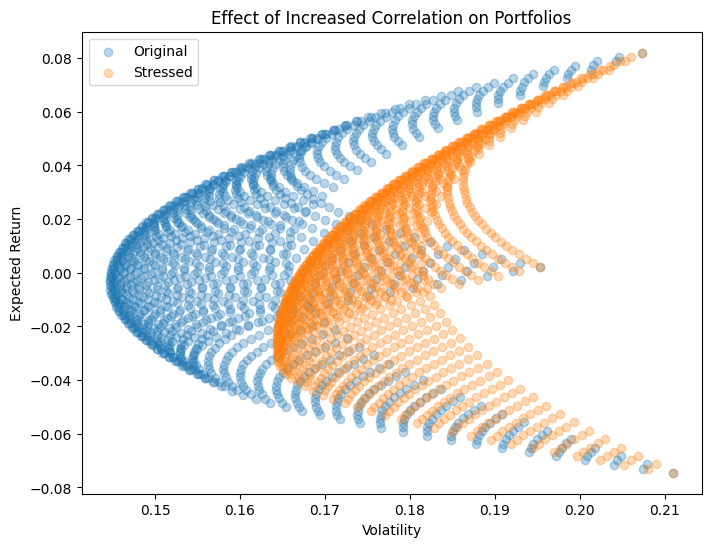

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Return"],
    alpha=0.3,
    label="Original"
)

plt.scatter(
    portfolio_df["Stressed Volatility"],
    portfolio_df["Return"],
    alpha=0.3,
    label="Stressed"
)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Effect of Increased Correlation on Portfolios")
plt.legend()
plt.show()


### 4. Market Stress Test (Correlation Breakdown)
During market crashes or severe liquidity crises, previously uncorrelated assets tend to drop together (meaning their correlations move closer to 1). By doubling the off-diagonal covariance elements, we simulate this type of systemic market stress.

Notice how the entire "Stressed" cloud shifts to the right compared to the "Original" cloud. The core takeaway here is that the "free lunch" of diversification breaks down precisely when you need it most; higher correlations mathematically increase the overall portfolio variance ($\sigma_p^2$).

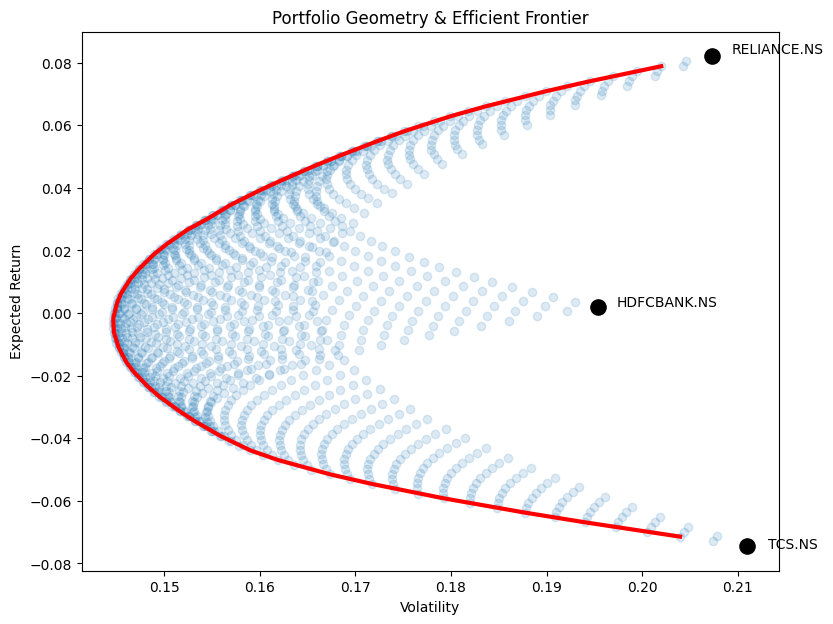

In [19]:
asset_vol = log_returns.std() * np.sqrt(TRADING_DAYS)

#Visualization
#TO DO : study this graph
plt.figure(figsize=(9,7))

# Portfolios
plt.scatter(portfolio_df["Volatility"], portfolio_df["Return"], alpha=0.15)

# Efficient Frontier
plt.plot(frontier_risk, frontier_return, color="red", linewidth=3)

# Assets
plt.scatter(asset_vol, mu, s=120, color="black")
for asset in mu.index:
    plt.text(asset_vol[asset]*1.01, mu[asset]*1.01, asset)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Portfolio Geometry & Efficient Frontier")
plt.show()


### 5. Portfolio Geometry & Individual Assets
This plot overlays the individual, standalone assets (represented by the black dots) onto the diversified portfolio cloud. This serves as the visual proof of Modern Portfolio Theory (MPT).

Notice how the leftmost edge of the portfolio cloud (the Minimum Variance Portfolio) is located further to the left than any single individual asset. Because the underlying assets are not perfectly correlated ($\rho < 1$), mixing them allows you to mathematically construct a portfolio that is actually *less risky* than the safest individual asset in the entire group.